In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")

In [3]:
data_root = "../analytical_solution_for_cylinder/output_results/"

data_dict = {}

for filename in ["derivative", "dphi1_dr", "dphi1_dx", "dphiu1_dx", "q", "sum"]:
    data_dict[filename] = np.loadtxt(data_root + filename + ".txt")

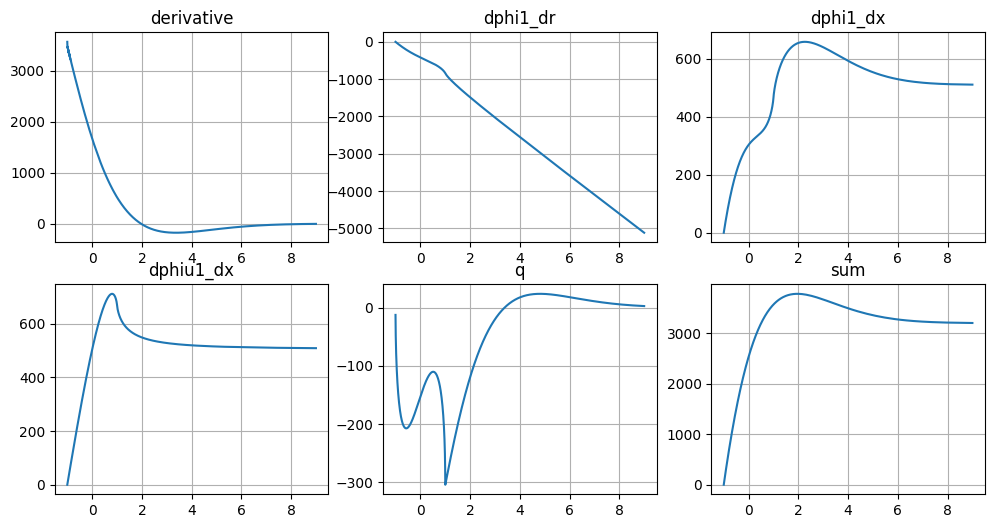

In [4]:
plt.subplots(2, 3, figsize=(12, 6))
plot_idx = 1

for filename in ["derivative", "dphi1_dr", "dphi1_dx", "dphiu1_dx", "q", "sum"]:
    plt.subplot(2, 3, plot_idx)
    plt.plot(data_dict[filename][:,0], data_dict[filename][:,1])
    plt.title(filename)
    plt.grid()
    plot_idx += 1

plt.show()

In [59]:
data_root = "../analytical_solution_for_cylinder/numerical_calculated/"

zs = np.loadtxt(data_root + 'z_out.txt')
Fy = np.loadtxt(data_root + 'Fy_out.txt')
Mz = np.loadtxt(data_root + 'Mz_out.txt')

In [60]:
gamma = 1.4
rho = 1.2255
p = 101330
Mach = 3
a = np.sqrt(gamma * p / rho)
V = Mach * a

In [61]:
dimensional_coeff = (gamma - 1) * 2 / (rho * V**2) * np.pi * rho * V

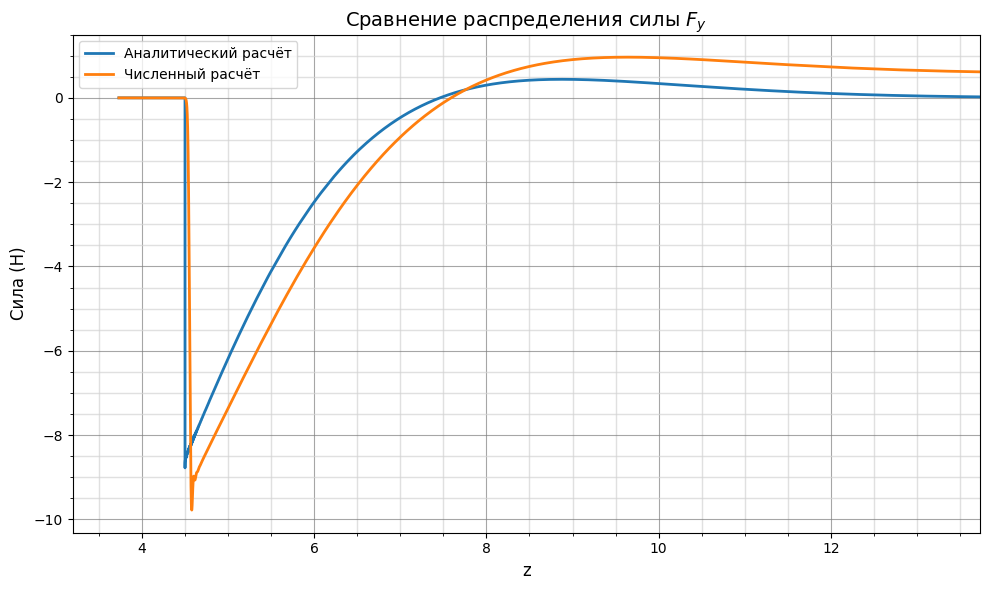

In [62]:
plt.figure(figsize=(10, 6))

plt.plot(
    np.hstack((
        np.linspace(zs.min(), data_dict["derivative"][:,0].min() + 5.5),
        data_dict["derivative"][:,0] + 5.5
    )),
    np.hstack((np.zeros(50), -data_dict["derivative"][:,1] * dimensional_coeff)),
    label='Аналитический расчёт',
    linewidth=2
)
plt.plot(zs, Fy, label=r'Численный расчёт', linewidth=2)

# --- Добавляем оформление ---
# 1. Сетка с основными и вспомогательными линиями
plt.grid(which='major', linestyle='-', linewidth=0.8, color='gray', alpha=0.7)
plt.grid(which='minor', linestyle='-', linewidth=1, color='lightgray', alpha=0.7)
plt.minorticks_on()

# 2. Подписи осей
plt.xlabel('z', fontsize=12)
plt.ylabel('Сила (Н)', fontsize=12)

# 3. Заголовок
plt.title(r'Сравнение распределения силы $F_y$', fontsize=14)

# 4. Легенда
plt.legend(loc='best', fontsize=10)

# 5. (Опционально) Настройка количества вспомогательных делений
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(4))  # 4 промежуточных деления между основными
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))

plt.xlim(right=max(zs))

plt.tight_layout()
plt.show()